In [1]:
import csv

# Data: Zone | Waste Generated (TPD) | Population (in Lakh)
data = [
    ["Zone", "Waste Generated (TPD)", "Population (in Lakh)"],
    ["North Shahdara", 1250, 20.36],
    ["South Shahdara", 1200, 20.06],
    ["Central", 1000, 15.84],
    ["City SP", 950, 6.05],
    ["Rohini", 950, 20.17],
    ["Najafgarh", 900, 14.66],
    ["South", 900, 14.60],
    ["West", 900, 17.04],
    ["Karol Bagh", 850, 9.04],
    ["Civil Lines", 800, 13.38],
    ["Keshav Puram", 800, 11.04],
    ["Narela", 500, 30.47],
    ["Total MCD", 11500, 192.71]
]

# Create CSV file
filename = "delhi_mcd_zones_waste_population.csv"

with open(filename, 'w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerows(data)

print(f"✅ CSV file created successfully: {filename}")
print("You can now open it in Excel or Google Sheets.")

✅ CSV file created successfully: delhi_mcd_zones_waste_population.csv
You can now open it in Excel or Google Sheets.


In [6]:
import pandas as pd

#Load your CSV file
df = pd.read_csv("delhi_mcd_zones_waste_population.csv")

#Remove Total MCD row
df = df[df["Zone"] != "Total MCD"]

#Create Waste per Person
df["Waste_per_Person"] = df["Waste Generated (TPD)"] / (df["Population (in Lakh)"] * 100000)

#Show result
print(df.head())

             Zone  Waste Generated (TPD)  Population (in Lakh)  \
0  North Shahdara                   1250                 20.36   
1  South Shahdara                   1200                 20.06   
2         Central                   1000                 15.84   
3         City SP                    950                  6.05   
4          Rohini                    950                 20.17   

   Waste_per_Person  
0          0.000614  
1          0.000598  
2          0.000631  
3          0.001570  
4          0.000471  


In [7]:
df["Waste_per_Person"] = df["Waste Generated (TPD)"] / (df["Population (in Lakh)"] * 100000)

In [8]:
mean_value = df["Waste_per_Person"].mean()

df["Risk"] = df["Waste_per_Person"].apply(
    lambda x: "High Risk" if x > mean_value else "Low Risk"
)

print(df[["Zone", "Risk"]])

              Zone       Risk
0   North Shahdara   Low Risk
1   South Shahdara   Low Risk
2          Central   Low Risk
3          City SP  High Risk
4           Rohini   Low Risk
5        Najafgarh   Low Risk
6            South   Low Risk
7             West   Low Risk
8       Karol Bagh  High Risk
9      Civil Lines   Low Risk
10    Keshav Puram  High Risk
11          Narela   Low Risk


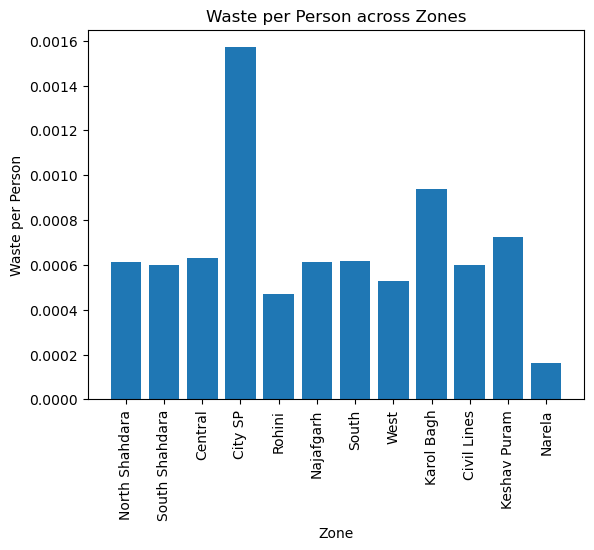

In [12]:
plt.bar(df["Zone"], df["Waste_per_Person"])

plt.xticks(rotation=90)
plt.title("Waste per Person across Zones")
plt.xlabel("Zone")
plt.ylabel("Waste per Person")

plt.show()

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[["Waste Generated (TPD)", "Population (in Lakh)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=0)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df[["Zone", "Cluster"]])

              Zone  Cluster
0   North Shahdara        0
1   South Shahdara        0
2          Central        0
3          City SP        0
4           Rohini        0
5        Najafgarh        0
6            South        0
7             West        0
8       Karol Bagh        0
9      Civil Lines        0
10    Keshav Puram        0
11          Narela        1


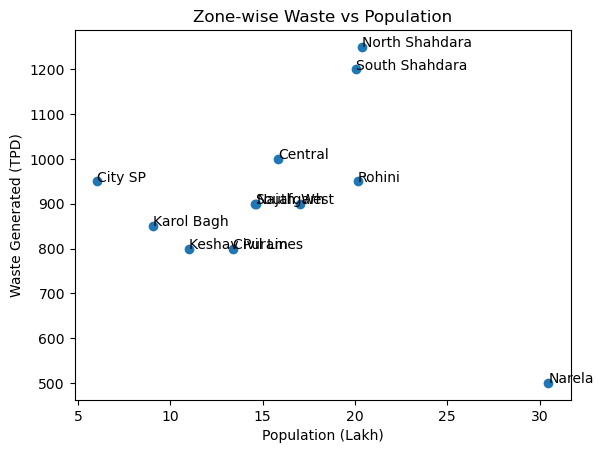

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df["Population (in Lakh)"], df["Waste Generated (TPD)"])
for i, txt in enumerate(df["Zone"]):
    plt.annotate(txt, (df["Population (in Lakh)"][i], df["Waste Generated (TPD)"][i]))

plt.xlabel("Population (Lakh)")
plt.ylabel("Waste Generated (TPD)")
plt.title("Zone-wise Waste vs Population")
plt.show()

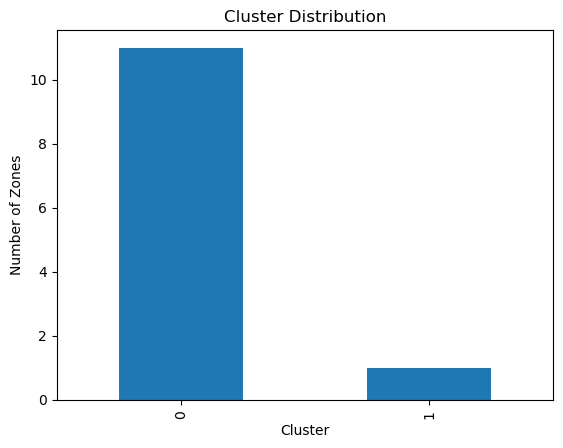

In [16]:
df["Cluster"].value_counts().plot(kind="bar")

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Zones")

plt.show()

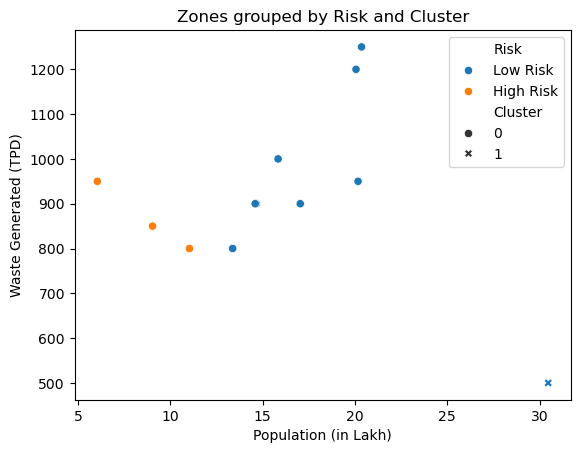

In [20]:
import seaborn as sns

sns.scatterplot(
    x=df["Population (in Lakh)"],
    y=df["Waste Generated (TPD)"],
    hue=df["Risk"],
    style=df["Cluster"]
)

plt.title("Zones grouped by Risk and Cluster")
plt.show()